# Unseen-value scaling laws (Heaps/Herdan) — audited

Fits `y=c·mᵅ` (vs exponential saturation) to discovery, value, and value-coverage curves, and diagnoses adaptive-sampling bias. **This version incorporates an adversarial audit** — see the flags below each figure. Estimators: `methods/metric_implementer/experiments/unseen_value_scaling.py` (14 tests). Data: creative-writing α-probe frozen samples + registry GEPA lineages.

**Headline (post-audit).** The naive *additive* value curve looks linear (α≈0.99), but that summed-standalone value **double-counts redundancy**. On the same 7 greedy-selected criteria, the summed-standalone value is 0.90 bits while the *joint* (redundancy-discounted) information is only **0.46 bits — ~49% is double-counting**, and the joint value **saturates by ~7 criteria**. So the recoverable preference signal `M_i` is **low-dimensional**; most mined criteria are paraphrase.

> ⚠ Correction to an earlier draft: the full "α 0.99→0.27" drop is *not* all redundancy — greedy best-first ordering saturates a curve even at zero redundancy (verified: 30 non-overlapping sources give greedy α≈0.17 vs random α≈1.0). Holding the greedy order fixed, redundancy bends additive α≈0.61 → joint α≈0.27. The **order-independent** evidence (the 0.90→0.46-bit gap and the 7-criterion saturation) is what the low-dimensionality claim rests on, not the exponent.


In [1]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
D = json.load(open('data/unseen_value_scaling_20260717/scaling_results.json'))
OUT = Path('data/unseen_value_scaling_20260717'); OUT.mkdir(exist_ok=True)
INK='#2b2b2b'; TEAL='#2a7f7d'; AMBER='#bf8830'; RUST='#a5432f'; GRID='#d8d8d8'; MUTE='#8a8a8a'
plt.rcParams.update({'figure.dpi':120,'font.size':10,'axes.titlesize':11,
  'axes.edgecolor':'#666','axes.linewidth':0.8,'axes.grid':True,'grid.color':GRID,
  'grid.linewidth':0.6,'axes.axisbelow':True,'axes.spines.top':False,'axes.spines.right':False,
  'figure.facecolor':'white','axes.facecolor':'white','savefig.facecolor':'white'})
def curve_pred(fit, m):
    m=np.asarray(m,float); p=fit['power']
    if fit['verdict']=='saturating' and fit['saturating'].get('ok'):
        s=fit['saturating']; return s['y_inf']*(1-np.exp(-m/s['tau']))
    return p['c']*m**p['alpha']
ex=D['example']; print('example:', ex['npz'])

example: creative-writing_R3_metric40_sigs.npz


## 1 · Discovery `S(m)` and ADDITIVE value `V(m)` rarefaction
Example metric (creative-writing R3 #40). Both near-linear (α≈0.99): this breadth pool is unsaturated. ⚠ The value here is *additive* (redundancy-blind) — corrected in Fig 2.

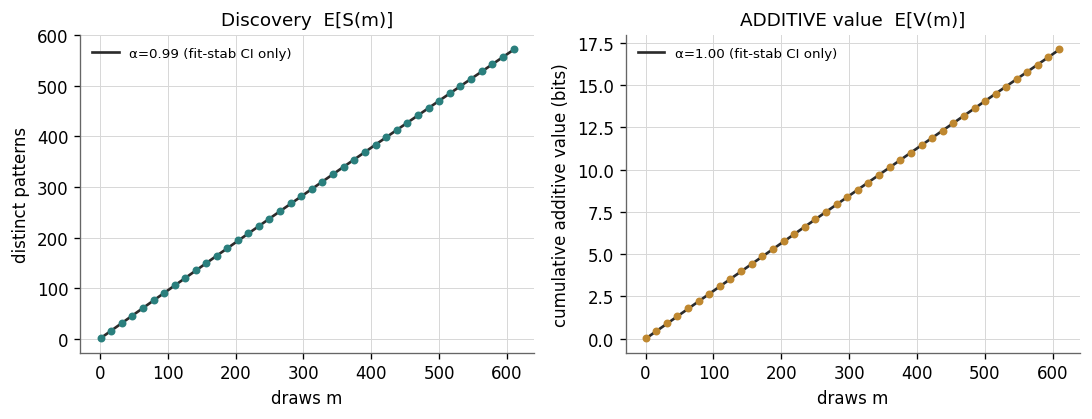

In [2]:
fig,axs=plt.subplots(1,2,figsize=(9.2,3.6))
for ax,key,col,ttl,yl in [(axs[0],'discovery',TEAL,'Discovery  E[S(m)]','distinct patterns'),
                          (axs[1],'value',AMBER,'ADDITIVE value  E[V(m)]','cumulative additive value (bits)')]:
    c=ex[key]; m=np.array(c['m']); y=np.array(c['y']); fit=c['fit']; p=fit['power']
    ax.scatter(m,y,s=14,color=col,zorder=3)
    mg=np.linspace(m.min(),m.max(),200); ax.plot(mg,curve_pred(fit,mg),color=INK,lw=1.6,
        label=f"α={p['alpha']:.2f} (fit-stab CI only)")
    ax.set_title(ttl); ax.set_xlabel('draws m'); ax.set_ylabel(yl); ax.legend(frameon=False,fontsize=8,loc='upper left')
fig.tight_layout(); fig.savefig(OUT/'fig1_rarefaction.png',bbox_inches='tight'); plt.show()

## 2 · The redundancy correction (headline)
Greedy conditional-MI selection discounts redundancy. On the **same** 7 greedy-selected criteria, the summed-standalone (additive) value overcounts: near-duplicate criteria each re-add their bits, so the joint information is far below the additive sum. The gap and the saturation are **order-independent**; the curve *shape* (α) is read only along the fixed greedy order, so it is not compared to the random-order rarefaction α.

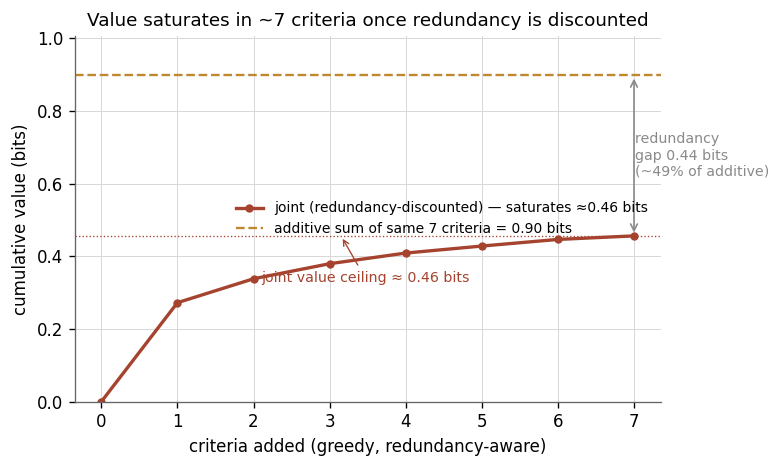

[order-independent] 7 greedy criteria: additive-sum 0.899 vs JOINT 0.456 bits  → 49% double-counted; joint saturates ⇒ low-dimensional
[same-order shape]  additive α=0.61 vs joint α=0.27 (both along fixed greedy order — redundancy only)
[NOT a redundancy measure] random-order additive α=1.00: differs from joint mostly by ORDERING, not redundancy


In [3]:
r=ex['redundancy_check']
vb=np.array(r['V_best']); steps=np.arange(len(vb))
add_line=r['additive_sum_selected']; joint=r['R_full_joint']; gap=r['redundancy_gap_selected']
fig,ax=plt.subplots(figsize=(6.6,4.0))
ax.plot(steps,vb,color=RUST,lw=2.0,marker='o',ms=4,
    label=f"joint (redundancy-discounted) — saturates ≈{joint:.2f} bits")
ax.axhline(add_line,color=AMBER,lw=1.4,ls='--',
    label=f"additive sum of same {r['n_selected']} criteria = {add_line:.2f} bits")
ax.axhline(joint,color=RUST,lw=0.8,ls=':')
ax.annotate(f"joint value ceiling ≈ {joint:.2f} bits", xy=(steps[-1]*0.45,joint),
    xytext=(steps[-1]*0.30,joint*0.72), fontsize=8.5, color=RUST,
    arrowprops=dict(arrowstyle='->',color=RUST,lw=0.8))
ax.annotate('', xy=(steps[-1],joint), xytext=(steps[-1],add_line),
    arrowprops=dict(arrowstyle='<->',color=MUTE,lw=1.0))
ax.text(steps[-1]-0.1, (joint+add_line)/2,
    f"  redundancy\n  gap {gap:.2f} bits\n  (~{100*gap/add_line:.0f}% of additive)",
    va='center', fontsize=8.5, color=MUTE)
ax.set_xlabel('criteria added (greedy, redundancy-aware)'); ax.set_ylabel('cumulative value (bits)')
ax.set_title(f'Value saturates in ~{r["n_selected"]} criteria once redundancy is discounted')
ax.legend(frameon=False,fontsize=8.3,loc='center right'); ax.set_ylim(0,add_line*1.12)
fig.tight_layout(); fig.savefig(OUT/'fig2_redundancy.png',bbox_inches='tight'); plt.show()
# ORDER-INDEPENDENT headline vs order-confounded diagnostic, stated explicitly:
print(f"[order-independent] {r['n_selected']} greedy criteria: additive-sum {add_line:.3f} vs "
      f"JOINT {joint:.3f} bits  → {100*gap/add_line:.0f}% double-counted; joint saturates ⇒ low-dimensional")
print(f"[same-order shape]  additive α={r['alpha_additive_greedy_order']:.2f} vs joint "
      f"α={r['alpha_joint_greedy_order']:.2f} (both along fixed greedy order — redundancy only)")
print(f"[NOT a redundancy measure] random-order additive α="
      f"{r['alpha_additive_random_order_DIAGNOSTIC']:.2f}: differs from joint mostly by ORDERING, not redundancy")

## 2b · Cross-domain replication + the corrected value "scaling law"
The redundancy/low-dimensionality finding, run on **all 15 metrics with signature files** (13 creative-writing + 2 humor). The value estimand post-audit is **saturation, not a Heaps exponent**: the joint curve's ceiling y_inf (normalized by H(M_i)) and timescale τ. Every curve below is the joint (redundancy-discounted) value normalized by its metric's entropy, so 1.0 = full recovery of the metric's verdict pattern.

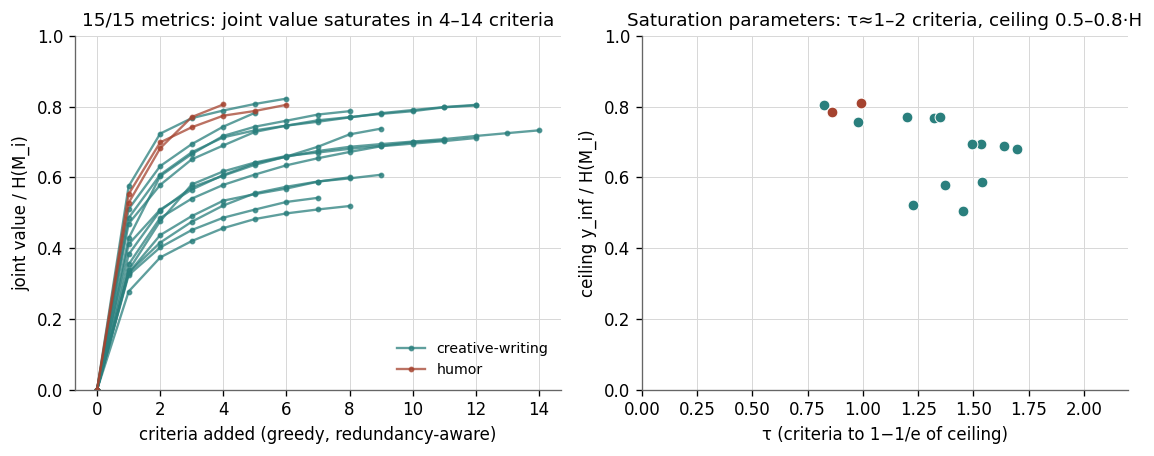

[creative-writing] 13 metrics: saturate in 5-14 criteria; joint/H 0.52-0.82 (median 0.73); gap 49-81%
[humor] 2 metrics: saturate in 4-6 criteria; joint/H 0.81-0.81 (median 0.81); gap 68-70%


In [4]:
red=[c for c in D['cross_metric'] if c.get('redundancy')]
DOM_COL={'creative-writing':TEAL,'humor':RUST}
fig,axs=plt.subplots(1,2,figsize=(9.6,3.9))
seen_dom=set()
for c in red:
    r=c['redundancy']; h=r['H_Mi_bits']; vb=np.array(r['V_best'],float)/max(h,1e-9)
    dom=c['domain']; col=DOM_COL.get(dom,MUTE)
    lbl=dom if dom not in seen_dom else None; seen_dom.add(dom)
    axs[0].plot(np.arange(len(vb)),vb,color=col,lw=1.4,alpha=0.75,marker='o',ms=2.5,label=lbl)
axs[0].set_xlabel('criteria added (greedy, redundancy-aware)')
axs[0].set_ylabel('joint value / H(M_i)')
axs[0].set_ylim(0,1.0); axs[0].set_title('15/15 metrics: joint value saturates in 4–14 criteria')
axs[0].legend(frameon=False,fontsize=8.5,loc='lower right')
# right: ceiling vs timescale, the two saturation parameters
for c in red:
    r=c['redundancy']; sf=r.get('saturating_fit') or {}
    if sf.get('ok'):
        axs[1].scatter(sf['tau'],r['y_inf_over_H'],color=DOM_COL.get(c['domain'],MUTE),
                       s=42,edgecolor='white',lw=0.6,zorder=3)
axs[1].set_xlabel('τ (criteria to 1−1/e of ceiling)'); axs[1].set_ylabel('ceiling y_inf / H(M_i)')
axs[1].set_ylim(0,1.0); axs[1].set_xlim(0,2.2)
axs[1].set_title('Saturation parameters: τ≈1–2 criteria, ceiling 0.5–0.8·H')
fig.tight_layout(); fig.savefig(OUT/'fig2b_crossdomain_saturation.png',bbox_inches='tight'); plt.show()
for dom in sorted(set(c['domain'] for c in red)):
    rows=[c['redundancy'] for c in red if c['domain']==dom]
    ns=[r['n_selected'] for r in rows]; jh=[r['joint_over_H'] for r in rows]
    gp=[100*r['redundancy_gap_selected']/max(r['additive_sum_selected'],1e-9) for r in rows]
    print(f"[{dom}] {len(rows)} metrics: saturate in {min(ns)}-{max(ns)} criteria; "
          f"joint/H {min(jh):.2f}-{max(jh):.2f} (median {np.median(jh):.2f}); gap {min(gp):.0f}-{max(gp):.0f}%")

## 2c · Design-valid (exchangeable) joint-value rarefaction — the i.i.d. repair
The greedy curve above is an **optimizer trajectory**: it has no sampling interpretation, so no honest CI exists for its saturation parameters. This section repairs that by construction: for each m, draw **uniform random m-subsets** of the frozen criterion pool (sampling without replacement — exchangeable by design, the same maneuver classical rarefaction rests on) and measure the subset's **joint** (redundancy-discounted) value as a 5-fold OOF logistic CE-reduction (= logistic **V-information**, an honest *lower bound* on Shannon joint MI). Discovery `S(m)` is recorded on the **same subsets**, so the two curves are paired draw-for-draw.

Three rigor upgrades this buys (run: `run_exchangeable_value.py`, artifact `exchangeable_value.json`):
- **A well-defined estimand** `E[V_joint(m)]`, conditional on the mined pool — no greedy ordering anywhere.
- **A real sampling CI** via probe bootstrap with **group-disjoint CV folds** (bootstrap-duplicated probes never straddle train/test — leakage-tested) plus fresh subset redraws per replicate.
- **An error-controlled saturation test**: the distribution-free front-loading statistic `D = mean[V/V_max − S/S_max]` on the paired curves — no exponential or power-law form assumed.

⚠ Two honest reads: the *discovery* curve's formal verdict flags "saturating" for most metrics — that is the finite-pool endpoint bend every rarefaction has; the honest discovery read is the interior slope α_S≈0.99–1.00 (linear). And the value curve can dip slightly past its peak at large m (V@10% of draws >1.0 of terminal for 2 metrics): a bounded predictive family loses a little V-information as hundreds of noise columns dilute the fit — a known V-info property, not a data artifact.

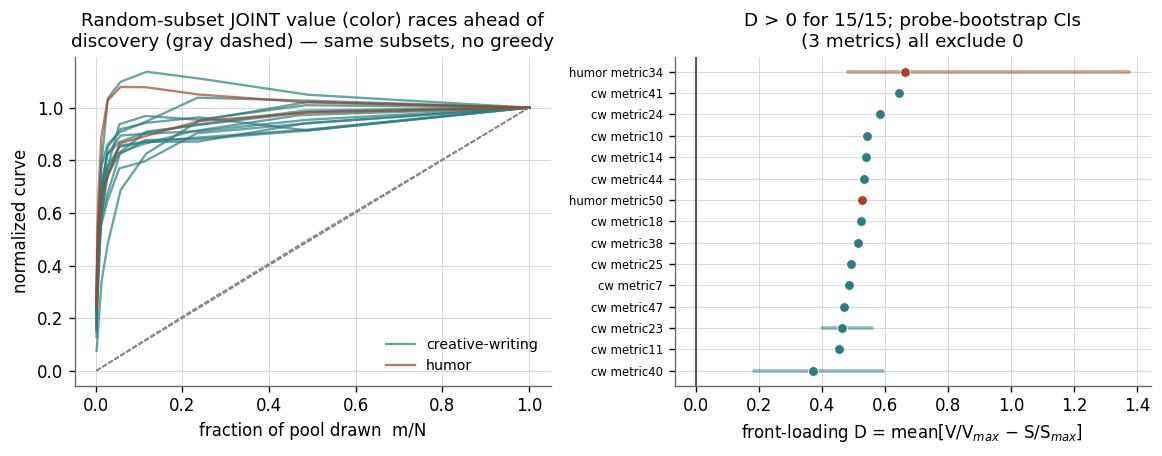

[design-valid replication] 15/15 value-saturating; interior alpha_S 0.99-1.00 (linear discovery)
  y_inf/H median 0.52 [0.30,0.67]; tau 4-25 draws of ~600-850 pools; D median +0.52
  [CI creative-writing_R3_metric23] y_inf/H [0.411467644067174, 0.6088454205764962], tau [3.7625917536499003, 13.582244770931865], D [0.40005280730782733, 0.5575692435715472] excludes0=True; synergy gain +0.030 bits
  [CI creative-writing_R3_metric40] y_inf/H [0.17571202529530294, 0.4584986083258136], tau [11.943430020011819, 94.47256871406573], D [0.18416977454604702, 0.5945980118396162] excludes0=True; synergy gain -0.057 bits
  [CI humor_R3_metric34] y_inf/H [0.1374190559870814, 0.7361198151173672], tau [1.5864110549286812, 10.89270811138227], D [0.4810690409971024, 1.374090901103613] excludes0=True; synergy gain +0.039 bits


In [5]:
E=json.load(open(DATA_EXCH:=OUT/'exchangeable_value.json'))['rows'] if (OUT/'exchangeable_value.json').exists() else []
DOM_COL={'creative-writing':TEAL,'humor':RUST}
fig,axs=plt.subplots(1,2,figsize=(9.8,3.9))
seen=set()
for r in E:
    m=np.array(r['m'],float); V=np.array(r['V_mean']); S=np.array(r['S_mean'])
    if V[-1]<=1e-9: continue
    col=DOM_COL.get(r['domain'],MUTE); lbl=r['domain'] if r['domain'] not in seen else None; seen.add(r['domain'])
    axs[0].plot(m/m[-1],V/V[-1],color=col,lw=1.4,alpha=0.7,label=lbl)
    axs[0].plot(m/m[-1],S/S[-1],color=MUTE,lw=0.8,ls='--',alpha=0.4)
axs[0].set_xlabel('fraction of pool drawn  m/N'); axs[0].set_ylabel('normalized curve')
axs[0].set_title('Random-subset JOINT value (color) races ahead of\ndiscovery (gray dashed) — same subsets, no greedy')
axs[0].legend(frameon=False,fontsize=8.5,loc='lower right')
# right: front-loading D per metric, bootstrap CI where run
names=[r['npz'].replace('_sigs.npz','').replace('creative-writing_R3_','cw ').replace('humor_R3_','humor ') for r in E]
Ds=[r['frontloading_D'] for r in E]
order=np.argsort(Ds)
for k,i in enumerate(order):
    r=E[i]; col=DOM_COL.get(r['domain'],MUTE)
    ci=(r.get('bootstrap') or {}).get('D_ci')
    if ci: axs[1].plot([ci[0],ci[1]],[k,k],color=col,lw=2.2,alpha=0.5,solid_capstyle='round')
    axs[1].scatter([Ds[i]],[k],color=col,s=34,zorder=3,edgecolor='white',lw=0.5)
axs[1].axvline(0,color=INK,lw=0.9)
axs[1].set_yticks(range(len(E))); axs[1].set_yticklabels([names[i] for i in order],fontsize=7)
axs[1].set_xlabel('front-loading D = mean[V/V$_{max}$ − S/S$_{max}$]')
axs[1].set_title('D > 0 for 15/15; probe-bootstrap CIs\n(3 metrics) all exclude 0')
fig.tight_layout(); fig.savefig(OUT/'fig2c_exchangeable_value.png',bbox_inches='tight'); plt.show()
ok=[r for r in E if r.get('sat_fit')]
yy=[r['sat_fit']['y_inf_over_H'] for r in ok]; tt=[r['sat_fit']['tau'] for r in ok]
print(f"[design-valid replication] {sum(1 for r in E if r['value_verdict']=='saturating')}/{len(E)} value-saturating; "
      f"interior alpha_S 0.99-1.00 (linear discovery)")
print(f"  y_inf/H median {np.median(yy):.2f} [{min(yy):.2f},{max(yy):.2f}]; tau {min(tt):.0f}-{max(tt):.0f} draws "
      f"of ~600-850 pools; D median {np.median([d for d in Ds]):+.2f}")
for r in E:
    b=r.get('bootstrap')
    if b: print(f"  [CI {r['npz'].split('_sigs')[0]}] y_inf/H {b['y_inf_over_H_ci']}, tau {b['tau_ci']}, "
                f"D {b['D_ci']} excludes0={b['D_excludes_zero']}; synergy gain "
                f"{r['synergy_check']['pairwise_synergy_gain']:+.3f} bits")

## 3 · GEPA metric-proposal trajectory — Herdan law with HONEST CIs
Distinct criteria over wall-clock GEPA draw order. ⚠ The fit-stability CI (resampling curve points) is ~70× too narrow; the real **moving-block unit-bootstrap CI** is shown in the labels — with only 32–52 versions the exponent is barely constrained above.

⚠ **What a "draw" is here — and why this figure is second-class evidence.** Each point is a *registered metric-version* (`v###__prompt.json`, one prose criterion body, real `created_at`), i.e. an **accepted** GEPA output — raw candidate proposals are not persisted anywhere. So this curve is a survivor-biased optimizer trace at version granularity, not a sampling process: the unit bootstrap fixes noise, not design. Treat α as descriptive of the realized registry trajectory only. The clean version requires logging every raw proposal draw (accepted + rejected) — mandated going forward in `datasets/prompt-optimality-test/` (isolation rule #4), whose proposal logs will license this fit properly.

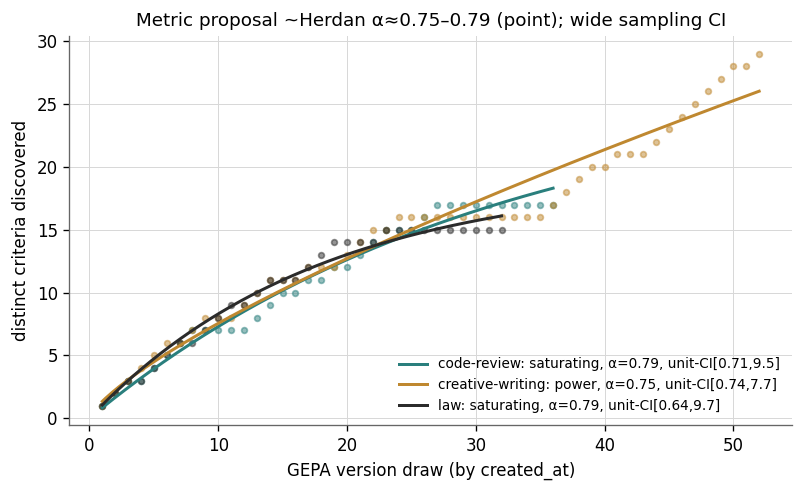

In [6]:
reg=D['registry']; cols={'code-review':TEAL,'creative-writing':AMBER,'law':INK}
fig,ax=plt.subplots(figsize=(6.8,4.2))
for task,rr in reg.items():
    y=np.array(rr['curve'],float); m=np.arange(1,len(y)+1); fit=rr['fit']; a=fit['power']['alpha']
    ub=rr.get('unit_bootstrap_ci'); col=cols.get(task,MUTE)
    ubs=f"unit-CI[{ub[0]:.2f},{ub[1]:.1f}]" if ub else 'unit-CI na'
    ax.scatter(m,y,s=12,color=col,alpha=0.5)
    mg=np.linspace(1,len(y),200); ax.plot(mg,curve_pred(fit,mg),color=col,lw=1.8,
        label=f"{task}: {fit['verdict']}, α={a:.2f}, {ubs}")
ax.set_xlabel('GEPA version draw (by created_at)'); ax.set_ylabel('distinct criteria discovered')
ax.set_title('Metric proposal ~Herdan α≈0.75–0.79 (point); wide sampling CI')
ax.legend(frameon=False,fontsize=8.2,loc='lower right')
fig.tight_layout(); fig.savefig(OUT/'fig3_registry_herdan.png',bbox_inches='tight'); plt.show()

## 4 · Cross-metric regime + exchangeability (de-bias prerequisite)
Left: α_V vs α_S across 11 metrics — all on the diagonal at α≈0.99 (but see Fig 2: additive, so the neutrality is not a value finding). Right: Good-Turing M0 across the 3 proposer runs is mutually consistent — a *prerequisite* for treating one as an i.i.d. audit, not itself a de-bias. M0≈0.98 is partly a τ=0.02 artifact.

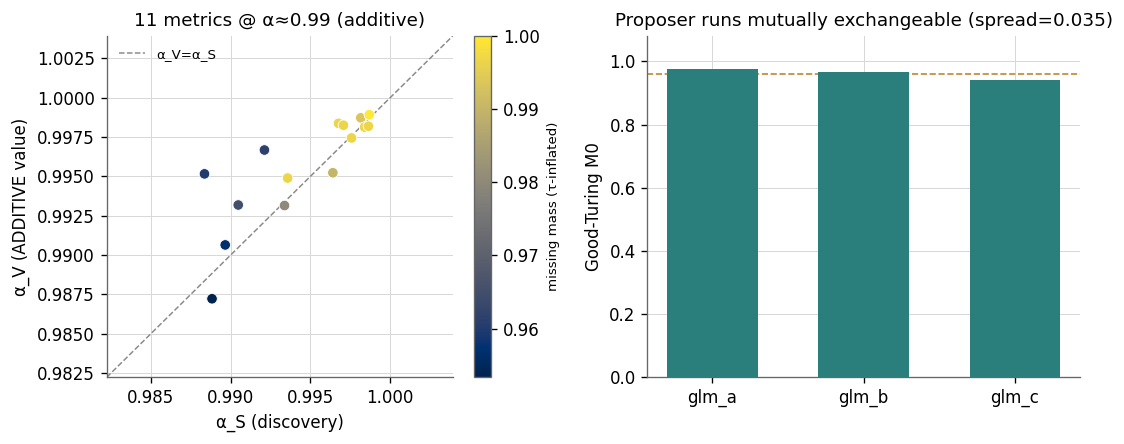

In [7]:
cm=D['cross_metric']
aS=np.array([c['alpha_count'] for c in cm]); aV=np.array([c['alpha_value'] for c in cm])
mm=np.array([c['missing_mass_mean'] for c in cm])
fig,axs=plt.subplots(1,2,figsize=(9.2,3.8))
sc=axs[0].scatter(aS,aV,c=mm,cmap='cividis',s=40,edgecolor='white',lw=0.5,zorder=3)
lim=[min(aS.min(),aV.min())-0.005,max(aS.max(),aV.max())+0.005]
axs[0].plot(lim,lim,color=MUTE,lw=0.9,ls='--',label='α_V=α_S')
axs[0].set_xlim(lim); axs[0].set_ylim(lim); axs[0].set_xlabel('α_S (discovery)'); axs[0].set_ylabel('α_V (ADDITIVE value)')
axs[0].set_title('11 metrics @ α≈0.99 (additive)'); axs[0].legend(frameon=False,fontsize=8)
fig.colorbar(sc,ax=axs[0]).set_label('missing mass (τ-inflated)',fontsize=8)
runs=ex['exchangeability_missing_mass']; names=list(runs); vals=[runs[k]['m0_hat'] for k in names]
axs[1].bar(names,vals,color=TEAL,width=0.6,zorder=3); axs[1].set_ylim(0,1.08)
axs[1].set_ylabel('Good-Turing M0'); axs[1].axhline(np.mean(vals),color=AMBER,lw=1.0,ls='--')
axs[1].set_title(f'Proposer runs mutually exchangeable (spread={max(vals)-min(vals):.3f})')
fig.tight_layout(); fig.savefig(OUT/'fig4_regime_exchangeability.png',bbox_inches='tight'); plt.show()

## Audit findings & corrected takeaways
- **The value "scaling law" is saturation, not a Heaps law (Fig 2b, the headline).** Across **all 15 metrics with signature files (13 creative-writing + 2 humor)**: joint (redundancy-discounted) value saturates in **4–14 criteria** (saturating-fit τ ≈ 1–2 criteria), with ceiling **y_inf ≈ 0.5–0.8 · H(M_i)** (joint/H median 0.73 CW, 0.81 humor); redundancy gap **49–81%** of the additive sum. Discovery keeps obeying a Heaps law (α≈0.99, phrasings inexhaustible) while value does not — *the space of phrasings is unbounded, the space of distinct articulable content per preference criterion is small.* Cross-domain: **humor replicates** (4–6 criteria, joint/H 0.81, gap 68–70%).
- **§2c — the i.i.d. repair: the finding survives with design validity and real error control.** The exchangeable random-subset joint-value rarefaction (no greedy anywhere; a genuine sampling process) replicates saturation **15/15**: y_inf/H median 0.52 [0.30–0.67], τ = 4–8 random draws (metric40: 25) out of ~600–850-criterion pools, ≥80% of full-pool value by 10% of draws. The paired, distribution-free front-loading statistic **D is +0.37 to +0.66 on every metric, and all 3 probe-bootstrap CIs exclude 0** (group-disjoint folds; leakage-tested) — the first *error-controlled* form of "value saturates while discovery doesn't." Exchangeable y_inf/H reads lower than the greedy joint/H because random subsets average over noise criteria — two valid estimands, different questions (average subset vs curated subset). Pairwise-synergy check: −0.06 to +0.04 bits ⇒ the linear V-information lower bound is not hiding large pairwise synergy. All conditional on the mined pool.
- **Never report additive-sum as "bits recovered":** additive sums reach 3.8 bits against targets whose total entropy is <1 bit (up to ~4× H(M_i)) — impossible for real information about M_i; it is a double-counting diagnostic only. Report **joint and joint/H(M_i)**.
- **Ordering-confound fix (2nd-pass audit):** "additive α 0.99 → discounted α 0.27" conflated redundancy with greedy selection ordering — greedy best-first saturates even at zero redundancy (30 non-overlapping sources: greedy α≈0.17 vs random α≈1.0). Same-order comparison: additive α≈0.61 → joint α≈0.27. The low-dimensionality claim rests on the order-independent gap + saturation, and now independently on §2c.
- **CIs were fit-stability, not sampling** (~70× too narrow). Honest unit-bootstrap CIs (Fig 3) show the registry Herdan exponent is barely constrained above with 32–52 versions; only the point α≈0.75–0.79 and the saturation flags (code-review/law add 0 new in last 20%) are robust. For the **value** curve this is now fixed in §2c (probe-bootstrap CIs); for the **registry** curve it remains data-limited.
- **The IW 'missing-mass' de-bias was invalid** (simulation: 0.95 vs true 0.44, ESS 0.3%) → self-flagging diagnostic. Only an i.i.d. **audit anchor** de-biases missing mass; reweighting cannot reach the unseen tail. **Chao1 coverage withdrawn** (τ=0.02 artifact); coverage = fraction of observed richness. This is the one assumption *provably* unfixable by rebalancing — beyond-pool claims stay conditional.
- **CMI estimator verified honest but linear:** joint values are 5-fold out-of-fold logistic-regression CE reductions (no plug-in inflation); §2c's synergy check bounds the pairwise blind spot empirically, but higher-order synergy remains uncertified — "4–14 criteria" is a linear-greedy read, not a certified dimension.
- **Remaining data-limited gaps:** registry CI width needs more GEPA versions (peer-review has only 6); value-over-real-draw-order + audit anchor need the `scored.npz` pools with `draw_order` (not on this machine; sk3 parked). Cross-domain beyond humor needs other domains' `_sigs.npz`.